In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def humedad_especifica(
    col_value="humedad_suelo_",
    year = 2018,
    sep=",",
):
    col_lugar="caicara"
    csv_path="../../data/raw/data set 1/dataset_orinoco_multivariado_final copy.csv"
    col_fecha="fecha"
    formato_fecha="%Y-%m-%d"

    df = pd.read_csv(csv_path, sep=sep)
    df.columns = df.columns.str.strip()

    meses = list(range(1, 13))
    nombres_meses = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
    lugares = ["ciudad_bolivar", "caicara", "palua", "ayacucho"]
    lugaresLabels = ["Ciudad Bolívar", "Caicara", "Palua", "Ayacucho"]
    lugaresIndex = list(range(1,5))
    # Convertir fecha y ordenar
    df[col_fecha] = pd.to_datetime(df[col_fecha], format=formato_fecha, errors="coerce")
    df = df.dropna(subset=[col_fecha]).sort_values(col_fecha)

    if df.empty:
        raise ValueError("No hay datos para el rango de años seleccionado.")

    plt.figure(figsize=(13, 5))

    for lugar in lugares:
        s = (
            df[df["fecha"].dt.year == year]
            .groupby(df["fecha"].dt.month)[f"{col_value}{lugar}"]
            .mean()
            .reindex(meses)
        )
        plt.plot(meses, s, marker="o", label=str(lugar), linestyle="-")

    plt.xticks(meses, nombres_meses)
    plt.xlabel("Mes")
    plt.ylabel("Humedad del suelo (%)")
    plt.title(f'Humedad del suelo ({year})')
    plt.grid(True, alpha=0.3)

    plt.legend(title="Puntos")
    plt.tight_layout()
    plt.show()

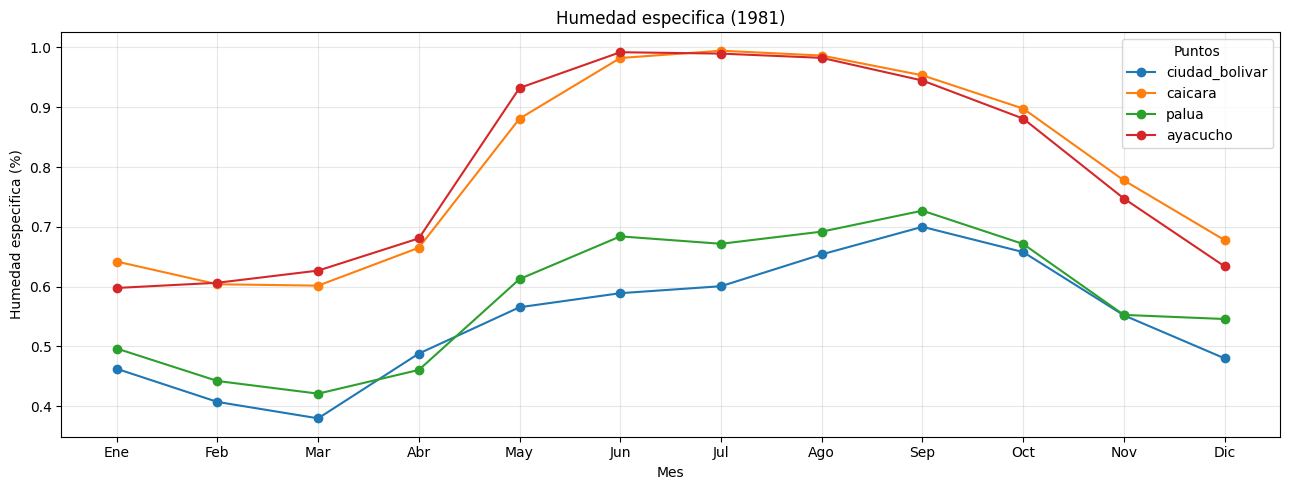

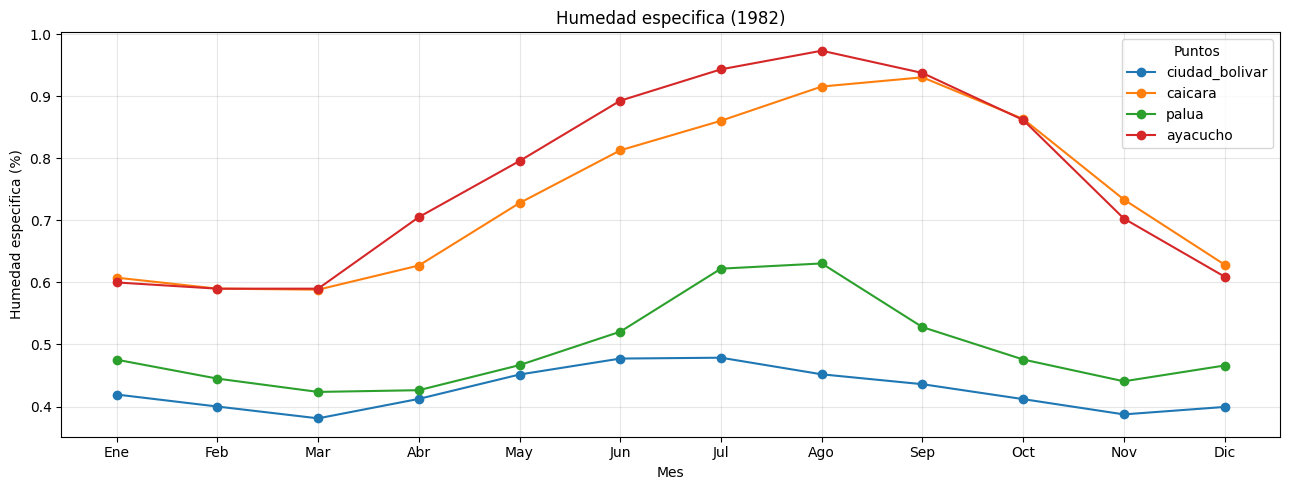

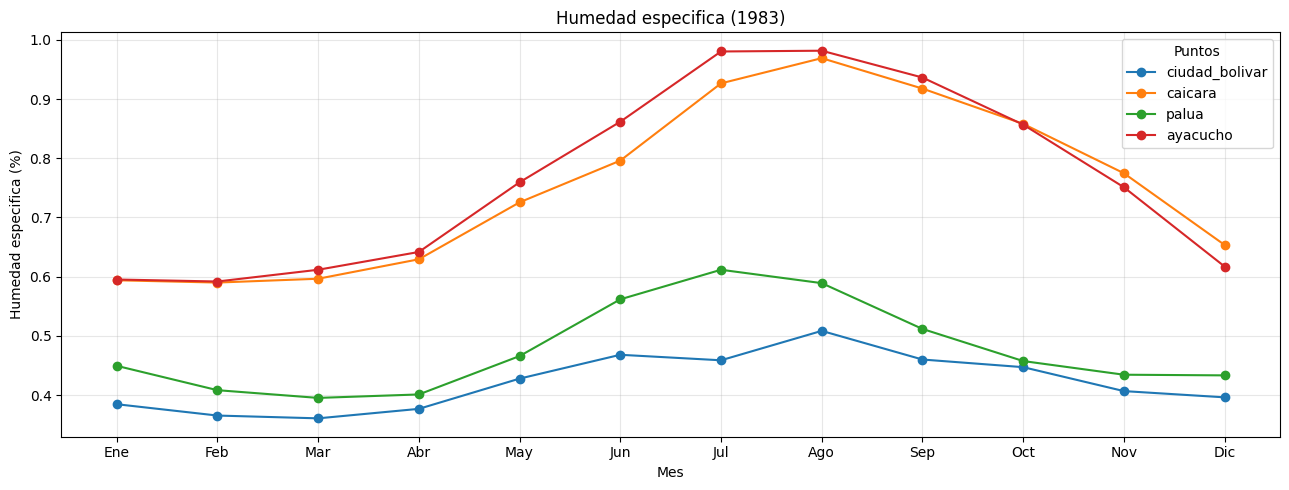

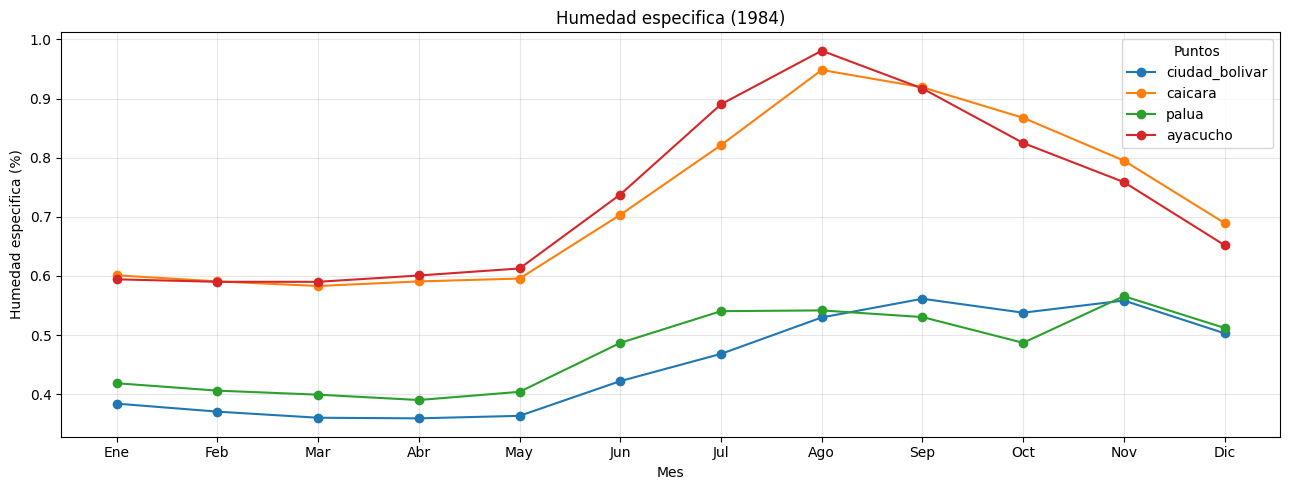

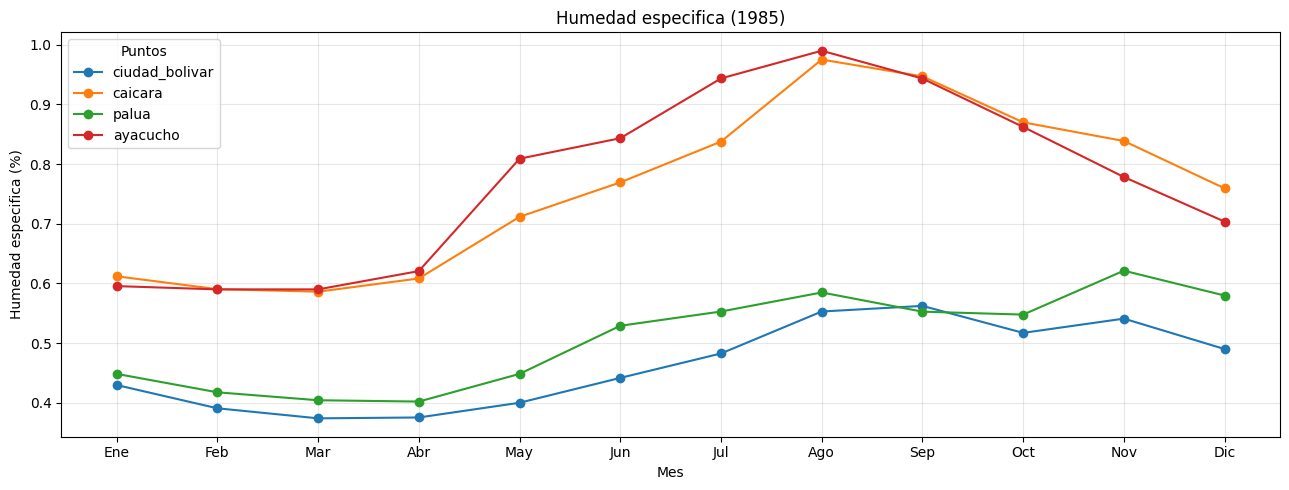

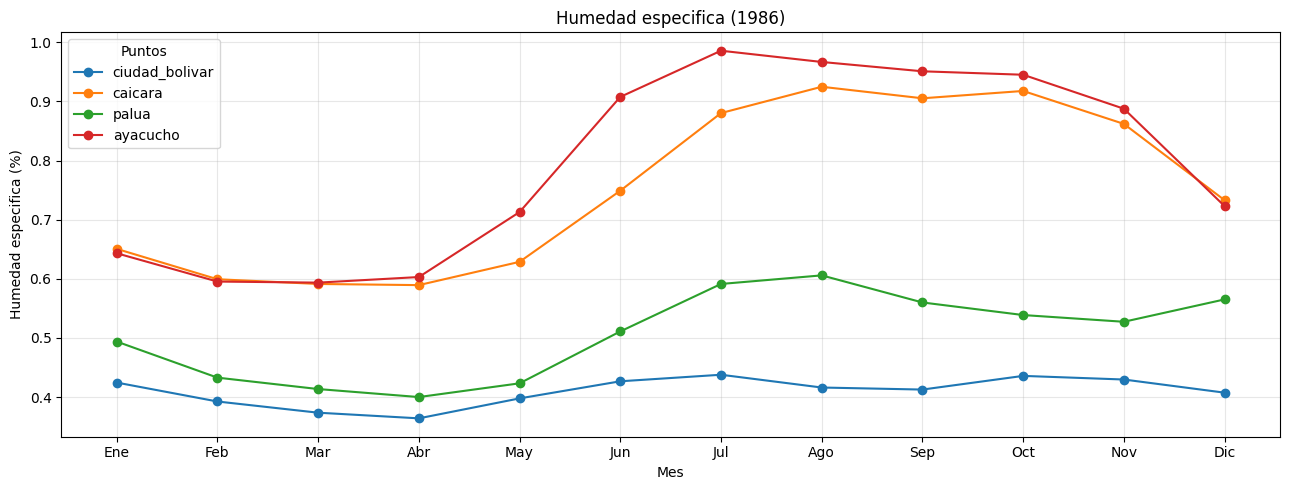

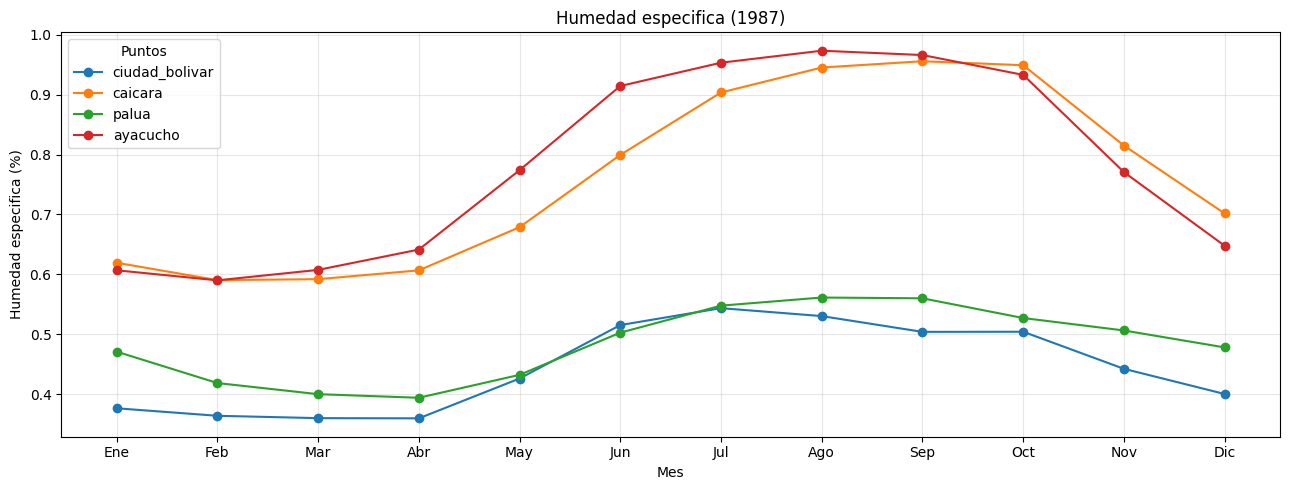

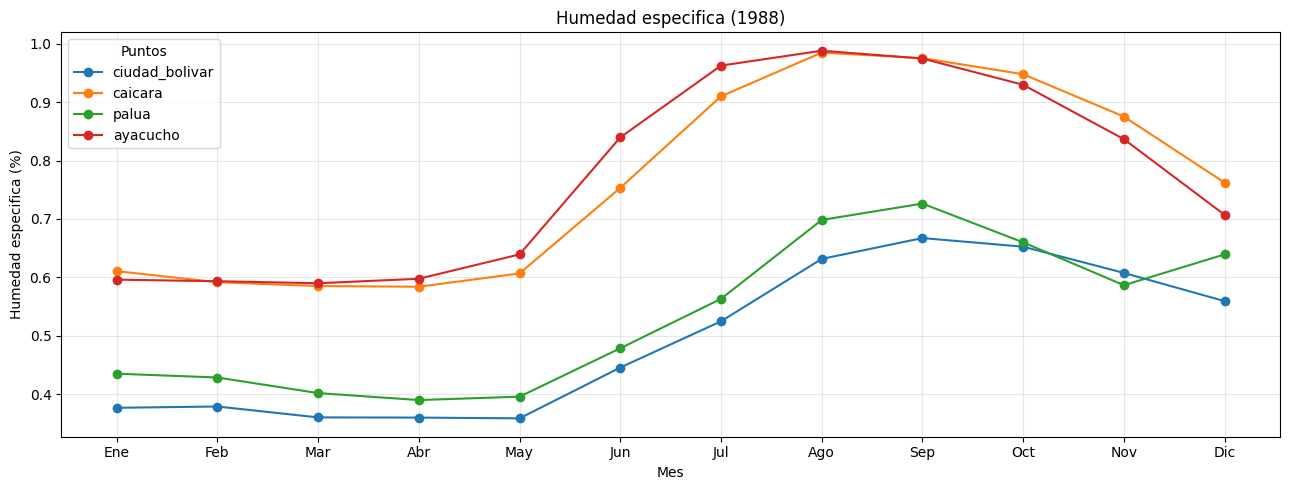

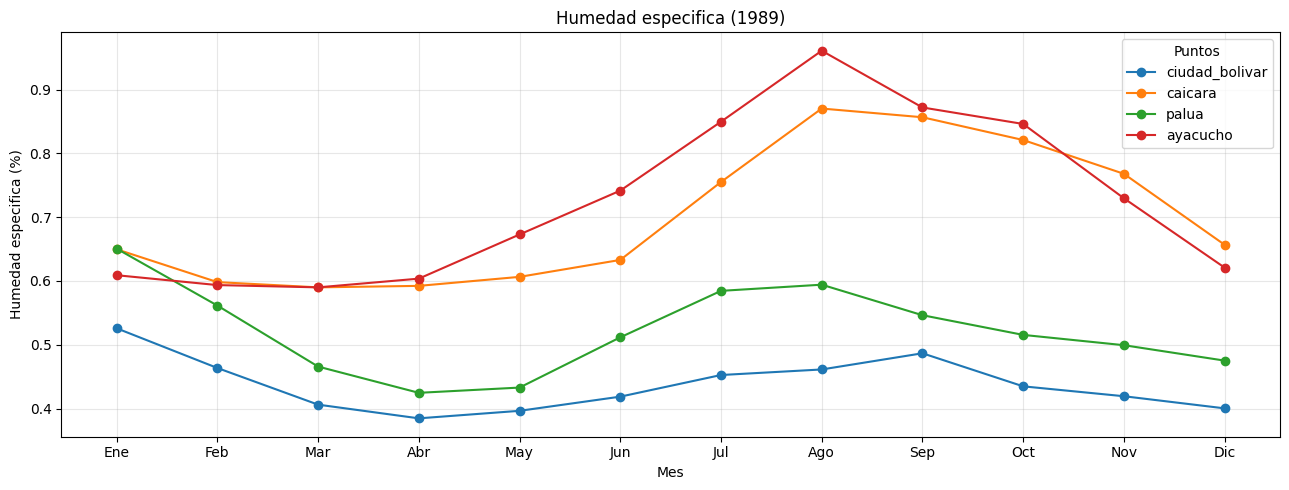

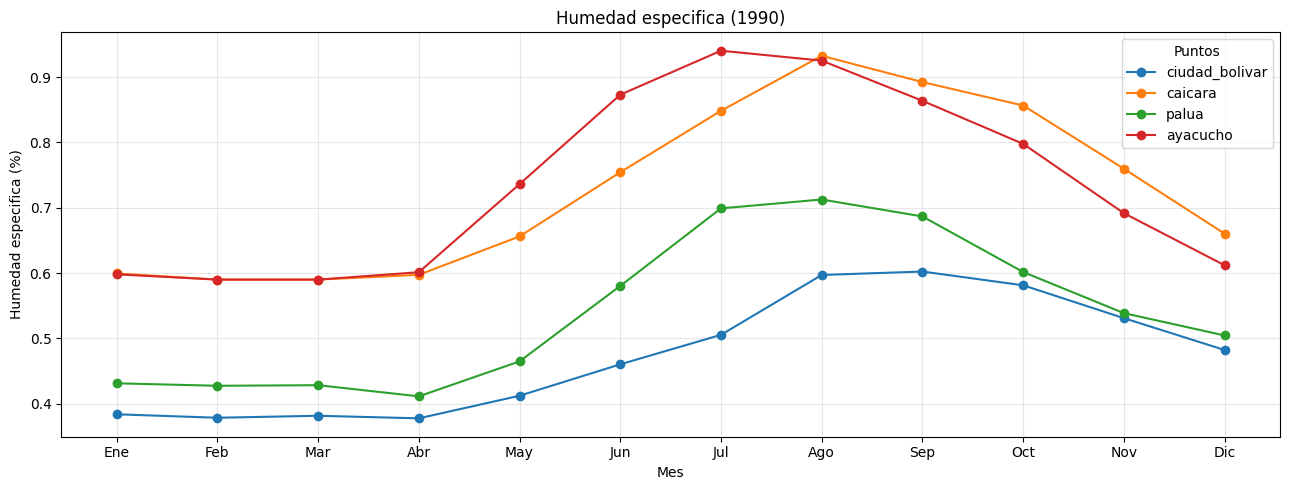

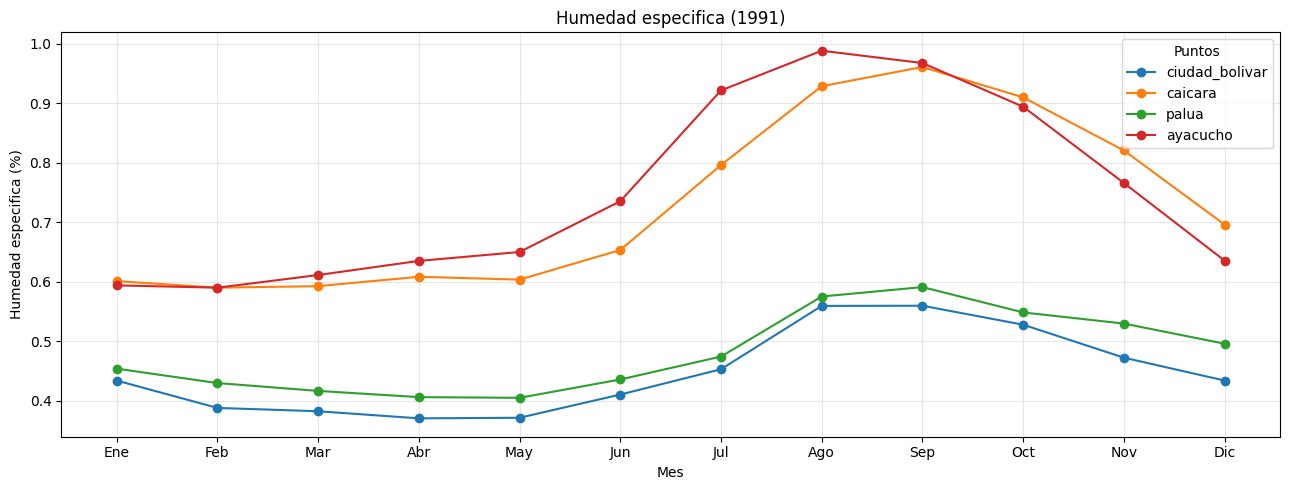

In [ ]:
for i in range(1981,2025):
    humedad_especifica(year=i)